## Klar for mappeoppgave 2?

* Neste mappeoppgave blir noe slikt som:
    - Hent datasett, 1 eller flere og gjør noe interessant
    - Vi vil ha 2 programmer hvor du undersøker en problemstilling, utforsker data eller gjør noe nyttig (real-time valutekonvertering el)
    - Vi ser gjerne at du i ett av programmene henter data programmatisk (med python, feks med`requests` eller `yfinance`)

# Plan
* Last inn dataset
    - header
    - les inn multicolumn
    - Gjør om til multicolumn
   
* Formattere data med replace
* Formattere datatype med astype
* bruke apply / map
* slice velge ut

In [310]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SSBENC = "ISO-8859-1"

# Multiindex dataset - datatyper - manglende datapunkt

In [311]:
befolkning_df = pd.read_csv("06913_20231018-082252.csv", sep=";", encoding=SSBENC)
befolkning_df

06913: Befolkning og endringer, etter region, år og statistikkvariabel
region                            år   Befolkning 1. januar Levendefødte Døde Fødselsoverskudd Innflyttinger Utflyttinger Nettoinnflytting                                      Folketilvekst                    
K_3001 Halden                     1951 23388                370          187  183              1451          1332         119                                                             302                    
                                  1952 23690                333          250  83               1633          1374         259                                                             342                    
                                  1953 24032                390          256  134              1388          1377         11                                                              145                    
                                  1954 24177                392          227  165              1702          1590         112                                                             277                    
...                                                                                                                                                                                       ...                    
K_Rest Delte kommuner og uoppgitt 2019 53951                437          536  -99              2243          2263         -20                                                            -109                    
                                  2020 0                    0            0    0                0             0            0                                                                 0                    
                                  2021 0                    0            0    0                0             0            0                                                                 0                    
                                  2022 0                    0            0    0                0             0            0                                                                 0                    
                                  2023 0                    0            0    0                0             0            0                                                                 0                    

[26281 rows x 1 columns]

* keyword-argumentet `header` gir oss hvilken linje headeren begynner på.
  - Vi teller fra 0
  - Tomme linjer telles ikke
* `index_col` gir hvilken kolonne vi vil bruke som index.
  - En liste med tall gir oss *multiindex* dataframe
* Vi kan ordne index etter lesningen også med `df.set_index(...)`

In [312]:
befolkning_df = pd.read_csv("06913_20231018-082252.csv", sep=";", encoding=SSBENC, header=1, index_col=[0,1])
befolkning_df

Befolkning 1. januar Levendefødte  \
region                            år                                        
K_3001 Halden                     1951                 23388          370   
                                  1952                 23690          333   
                                  1953                 24032          390   
                                  1954                 24177          392   
                                  1955                 24454          374   
...                                                      ...          ...   
K_Rest Delte kommuner og uoppgitt 2019                 53951          437   
                                  2020                     0            0   
                                  2021                     0            0   
                                  2022                     0            0   
                                  2023                     0            0   

                                       Døde Fødselsoverskudd Innflyttinger  \
region                            år                                         
K_3001 Halden                     1951  187              183          1451   
                                  1952  250               83          1633   
                                  1953  256              134          1388   
                                  1954  227              165          1702   
                                  1955  257              117          1548   
...                                     ...              ...           ...   
K_Rest Delte kommuner og uoppgitt 2019  536              -99          2243   
                                  2020    0                0             0   
                                  2021    0                0             0   
                                  2022    0                0             0   
                                  2023    0                0             0   

                                       Utflyttinger Nettoinnflytting  \
region                            år                                   
K_3001 Halden                     1951         1332              119   
                                  1952         1374              259   
                                  1953         1377               11   
                                  1954         1590              112   
                                  1955         1408              140   
...                                             ...              ...   
K_Rest Delte kommuner og uoppgitt 2019         2263              -20   
                                  2020            0                0   
                                  2021            0                0   
                                  2022            0                0   
                                  2023            0                0   

                                       Folketilvekst  
region                            år                  
K_3001 Halden                     1951           302  
                                  1952           342  
                                  1953           145  
                                  1954           277  
                                  1955           144  
...                                              ...  
K_Rest Delte kommuner og uoppgitt 2019          -109  
                                  2020             0  
                                  2021             0  
                                  2022             0  
                                  2023             0  

[26280 rows x 8 columns]

## Multiindeks dataframe

* I et multiindeks dataframe er indeksen en liste med tupler
* For eksempel: `[(Alta, 1951), (Alta, 1952), ... , (Ålesund, 2021), (Ålesund, 2022), (Ålesund,2023)]`
* Det kan være en ryddig måte å organisere dataen på, men kan bli litt vanskeligere å bruke
* Man kan alltid bruke `df.reset_index()` til å gå tilbake til en flat tabell

In [313]:
befolkning_df.index

MultiIndex([(                    'K_3001 Halden', 1951),
            (                    'K_3001 Halden', 1952),
            (                    'K_3001 Halden', 1953),
            (                    'K_3001 Halden', 1954),
            (                    'K_3001 Halden', 1955),
            (                    'K_3001 Halden', 1956),
            (                    'K_3001 Halden', 1957),
            (                    'K_3001 Halden', 1958),
            (                    'K_3001 Halden', 1959),
            (                    'K_3001 Halden', 1960),
            ...
            ('K_Rest Delte kommuner og uoppgitt', 2014),
            ('K_Rest Delte kommuner og uoppgitt', 2015),
            ('K_Rest Delte kommuner og uoppgitt', 2016),
            ('K_Rest Delte kommuner og uoppgitt', 2017),
            ('K_Rest Delte kommuner og uoppgitt', 2018),
            ('K_Rest Delte kommuner og uoppgitt', 2019),
            ('K_Rest Delte kommuner og uoppgitt', 2020),
            ('K

# Indeksering av multiindex dataframe 1

* Vi kan bruke `.loc[...]` som vanlig, men nå med 2 indekser, feks:
   - `df.loc[index0, index1]`
   - `df.loc[index0,index1][kolonne]
   - `df.loc[index0,index1][[kolonne1, kolonne2]]
* Eventuelt kan vi bruke kun første indeks, som gir oss «undertabellen» til feks "Halden"

In [314]:
data_halden_1955 = befolkning_df.loc["K_3001 Halden", 1955]
utflyttinger_halden_55 = befolkning_df.loc["K_3001 Halden", 1955]["Utflyttinger"]
in_ut_halden_55 = befolkning_df.loc["K_3001 Halden",1955][["Utflyttinger", "Innflyttinger"]]
befolkning_halden = befolkning_df.loc["K_3001 Halden"]
befolkning_halden

,Befolkning 1. januar,Levendefødte,Døde,Fødselsoverskudd,Innflyttinger,Utflyttinger,Nettoinnflytting,Folketilvekst
år,,,,,,,,
1951,23388,370,187,183,1451,1332,119,302
1952,23690,333,250,83,1633,1374,259,342
1953,24032,390,256,134,1388,1377,11,145
1954,24177,392,227,165,1702,1590,112,277
1955,24454,374,257,117,1548,1408,140,144
...,...,...,...,...,...,...,...,...
2019,31177,257,299,-42,1440,1208,232,196
2020,31373,254,284,-30,1428,1383,45,14
2021,31387,260,311,-51,1446,1333,113,57


# Indeksering av multiindex dataframe 2

* Indeksen er nå et tuple (index0, index1)
* Dersom man vil slice eller oppgi kolonne i samme `.loc[]` må man ta hensyn til dette:
    - `df.loc[(index0,index1), kolonne]`
    - `df.loc[(index0,index1), [kolonne1,kolonne2]]
   

In [315]:
data_halden_1955 = befolkning_df.loc[("K_3001 Halden", 1955)]
utflyttinger_halden_55 = befolkning_df.loc[("K_3001 Halden", 1955),"Utflyttinger"]
in_ut_halden_55 = befolkning_df.loc[("K_3001 Halden",1955),["Utflyttinger", "Innflyttinger"]]

## Case

Vi vil finne gjennomsnittlig innflytting til Halden mellom 1960 og 1965.
Vi støter på et par problemer:
* SSB har brukt ".." for manglende data, mens pandas bruker np.NaN
* Dataen er da blitt lagret som tekststrenger

Vi bruker `df.replace()` til å erstatte ".." med NaN, og `df.astype` til å angi datatype

In [355]:
befolkning_df = pd.read_csv("06913_20231018-082252.csv", sep=";", encoding=SSBENC, header=1)
befolkning_df.set_index(["region", "år"], inplace=True)
befolkning_df.replace('..', np.NaN, inplace=True)
befolkning_df = befolkning_df.astype({"Fødselsoverskudd": "float", "Utflyttinger": "Int32"})
befolkning_df = befolkning_df.astype("Int64")
befolkning_df.dtypes
snitt = befolkning_df.loc["K_3001 Halden"].loc[1960:1965]["Innflyttinger"].mean()
print(f"Gjennomsnittlig innflytting til Halden mellom '60 og '65 var {int(snitt)}")

Gjennomsnittlig innflytting til Halden mellom '60 og '65 var 1691


In [361]:
# Kommunene er lagt inn med K-nummer.
# Hvordan finner vi fram til riktig indeks?

# Vi kan reformatere indeksen slik at den kun inneholder kommunenavn
streng = "K_3001 Østre toten og omegn"
def formater_index(streng):
    kommune = streng.split()[1:]
    return " ".join(kommune)
# Hva skjer med Øvre Årdal eller Vestre Toten?
df_ny = befolkning_df.reset_index()
df_ny["region"] = befolkning_df.reset_index()["region"].map(formater_index)
df_ny = df_ny.set_index(["region", "år"])
df_ny

Befolkning 1. januar  Levendefødte  Døde  \
region                     år                                               
Halden                     1951                 23388           370   187   
                           1952                 23690           333   250   
                           1953                 24032           390   256   
                           1954                 24177           392   227   
                           1955                 24454           374   257   
...                                               ...           ...   ...   
Delte kommuner og uoppgitt 2019                 53951           437   536   
                           2020                     0             0     0   
                           2021                     0             0     0   
                           2022                     0             0     0   
                           2023                     0             0     0   

                                 Fødselsoverskudd  Innflyttinger  \
region                     år                                      
Halden                     1951               183           1451   
                           1952                83           1633   
                           1953               134           1388   
                           1954               165           1702   
                           1955               117           1548   
...                                           ...            ...   
Delte kommuner og uoppgitt 2019               -99           2243   
                           2020                 0              0   
                           2021                 0              0   
                           2022                 0              0   
                           2023                 0              0   

                                 Utflyttinger  Nettoinnflytting  Folketilvekst  
region                     år                                                   
Halden                     1951          1332               119            302  
                           1952          1374               259            342  
                           1953          1377                11            145  
                           1954          1590               112            277  
                           1955          1408               140            144  
...                                       ...               ...            ...  
Delte kommuner og uoppgitt 2019          2263               -20           -109  
                           2020             0                 0              0  
                           2021             0                 0              0  
                           2022             0                 0              0  
                           2023             0                 0              0  

[26280 rows x 8 columns]

* `Series.map(funksjon)` kjører en funksjon over dataen i en serie
* `apply` ([doc](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html)) gjør samme jobb for dataframes

* Vi kan også lage en funksjon som finner riktig indeks for kommunen

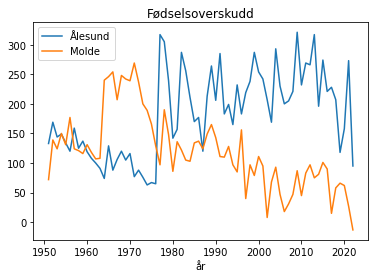

In [318]:
def finn_kommune(tekst_streng):
    for k, y in befolkning_df.index:
        if tekst_streng in k:
            return k
        
befolkning_df.loc[finn_kommune("Ålesund")]["Fødselsoverskudd"].plot(label="Ålesund")
befolkning_df.loc[finn_kommune("Molde")]["Fødselsoverskudd"].plot(label="Molde")
plt.legend()
plt.title("Fødselsoverskudd")
plt.show()

## Avansert slicing

Velg følgende data:
* Levendefødte og døde mellom 1990 og 1995 i Østre Toten og Vanylven
* Slicing på multiindex dataframes krever at dataen er sortert på riktig måte
* Man kan sortere indexen med `df.sort_index()`
* Det kan fort bli komplisert å slice slike dataframes

In [339]:
molde = finn_kommune("Molde")
ålesund = finn_kommune("Ålesund")
befolkning_df.sort_index(inplace=True)
#Metode 1: Slice begge indeksene og velge ut kolonne
befolkning_df.loc[(molde, 1950):(ålesund,1960),["Døde", "Nettoinnflytting"]]

Døde  Nettoinnflytting
region         år                          
K_1506 Molde   1951    74               108
               1952    85               197
               1953    73               204
               1954    69               156
               1955    83               -76
...                   ...               ...
K_1507 Ålesund 1956    64               -40
               1957    61               -59
               1958    64              -108
               1959    72              -123
               1960    68               -93

[83 rows x 2 columns]

In [351]:
#Metode 2: med .loc[index0, index1, :] [[kolonne1, kolonne2, ...]] 
befolkning_df.loc[[finn_kommune("Østre Toten"), finn_kommune("Vanylven")], 1990:1995, :][["Levendefødte", "Døde"]]

Levendefødte  Døde
region             år                      
K_3442 Østre Toten 1990           181   202
                   1991           148   168
                   1992           170   176
                   1993           174   173
                   1994           170   171
                   1995           146   189
K_1511 Vanylven    1990            46    40
                   1991            48    38
                   1992            53    52
                   1993            45    50
                   1994            49    42
                   1995            47    59

In [354]:
# Metode 3:
# Først velg ut kommunene i eget dataframe
# Deretter med .loc[(slice(None):slice(startår,sluttår)), [kolonne1, kolonne2,...]]

utvalgte_kommuner = befolkning_df.loc[[finn_kommune("Østre Toten"), finn_kommune("Vanylven")]]
utvalgte_kommuner.sort_index(inplace=True)
utvalgte_kommuner.loc[( slice(None), slice(1990,1995) ), ["Døde", "Levendefødte"]]

Døde  Levendefødte
region             år                      
K_1511 Vanylven    1990    40            46
                   1991    38            48
                   1992    52            53
                   1993    50            45
                   1994    42            49
                   1995    59            47
K_3442 Østre Toten 1990   202           181
                   1991   168           148
                   1992   176           170
                   1993   173           174
                   1994   171           170
                   1995   189           146

In [349]:
molde = finn_kommune("Molde")
befolkning_df.loc[(molde, 1950):(molde,1960)]
#a = befolkning_df.loc[[finn_kommune("Østre Toten"), finn_kommune("Vanylven")]].loc[finn_kommune("Østre Toten")]
a = befolkning_df.loc[[finn_kommune("Østre Toten"), finn_kommune("Vanylven")]]
a = a.sort_values(by=['region','år'],ascending=[True,True])
#a = a.loc[:,1990:1995,:][["Døde", "Levendefødte"]]
#a = a.loc[  :(Alle kommuner) , slice av år, :(alle kolonner)  ][  [Liste av kolonner] ]
#a = a.loc[[finn_kommune("Østre Toten"), finn_kommune("Vanylven")],1990:1995,:][["Døde", "Levendefødte"]]
#a = a.loc[(slice[finn_kommune("Østre Toten"), finn_kommune("Vanylven")],1990):(slice[finn_kommune("Østre Toten"), finn_kommune("Vanylven")],1995),"Døde"]

df2 = befolkning_df.loc[[finn_kommune("Østre Toten"), finn_kommune("Vanylven")]]
df2.sort_index(inplace=True)
df2.loc[:,1990:1995,:][["Døde", "Levendefødte"]]
df2.loc[(slice(None), slice(1990,1995)), ["Døde", "Levendefødte"]]


Døde  Levendefødte
region             år                      
K_1511 Vanylven    1990    40            46
                   1991    38            48
                   1992    52            53
                   1993    50            45
                   1994    42            49
                   1995    59            47
K_3442 Østre Toten 1990   202           181
                   1991   168           148
                   1992   176           170
                   1993   173           174
                   1994   171           170
                   1995   189           146